
<h1 style="text-align:center;">CREDIT CARD APPROVAL PREDICTION</h1>

<h4>Team: RJN</h4>
Ravisankar Chengannagari<br>
Jake (Dong Gyu Noh)<br>
Nikhil Krishna Chowdary Jampala<br>

<h2>INTRODUCTION</h2>

Our goal in this project is to build a reliable **credit-approval prediction model** that helps lenders decide whether to issue a new credit card to an applicant. We start with two real-world datasets from Kaggle:

1. **Application Records** – Demographics, income, assets and family info for ~438 k applicants  
2. **Credit-Card History** – Month-by-month payment status for those applicants (1 M+ rows)

We combine them to:

- **Label** each applicant as “approved” if they appear in the credit-history table  
- **Clean & transform** fields (age, employment years, log-income, missing occupations)  
- **Explore** patterns via univariate and bivariate plots  
- **Train** a LightGBM model (with 80/20 train/test split) using both numeric and categorical features  
- **Evaluate** performance with ROC-AUC, precision/recall, confusion matrices, and calibration

In the end, our baseline model achieves **~0.85 ROC-AUC** on held-out data. Next, we’ll look at ways to tune, improve precision, and add richer credit-history features.  

<center><img src="https://pngimg.com/d/credit_card_PNG87.png"></center>

In [ ]:
#imported required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imbpipeline
import warnings
warnings.filterwarnings('ignore')

<h2>DATA COLLECTION</h2>

- **Source:** Kaggle “Credit Card Approval Prediction” datasets  
- **Files loaded:**  
  1. `application_record.csv` – **438 557** applicants × **18** fields  
     - e.g. `ID`, `CODE_GENDER`, `AMT_INCOME_TOTAL`, `NAME_EDUCATION_TYPE`, `DAYS_BIRTH`, `OCCUPATION_TYPE`, etc.  
  2. `credit_record.csv` – **1 048 575** monthly entries × **3** fields  
     - `ID` (applicant), `MONTHS_BALANCE` (0 = most recent month, –1 last month…), and `STATUS` (0 = on time, 1–5 months late, X = no payment due, C = closed)  

- **Loading code:**  
  
  application_data = pd.read_csv('application_record.csv')
  
  credit_card_data = pd.read_csv('credit_record.csv')

In [ ]:
#reading application records
application_data = pd.read_csv('application_record.csv')

In [ ]:
#reading creadit card records
credit_card_data = pd.read_csv('credit_record.csv')

In [ ]:
#top 5 rows of application records
application_data.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [ ]:
#top 5 rows of credit card records
credit_card_data.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [ ]:
#we can see the information of the application data
application_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [ ]:
#we can see the information of credit card data
credit_card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [ ]:
#the number of rows and columns of application data
application_data.shape

(438557, 18)

From the above result, we can see that the application data has 18 columns and 438557 rows.

In [ ]:
#the number of rows and columns of credit card data
credit_card_data.shape

(1048575, 3)

From the above result, we can see that the credit card data has 3 columns and 1048575 rows.

<h2>DATA PREPARATION</h2>


In this section we:


1. **Created our label**  
   - Built `TARGET_APPROVED` by marking any applicant ID present in the credit table as “approved” (1), others as “not approved” (0).

2. **Handled missing values**  
   - Filled 30% missing `OCCUPATION_TYPE` with `"Unknown"`.  
   - Converted the special code `365243` in `DAYS_EMPLOYED` to NaN.

3. **Engineered key features**  
   - **Age in years**: `AGE_YEARS = (-DAYS_BIRTH / 365).round(1)`  
   - **Employment years**: `EMPLOY_YEARS = (-DAYS_EMPLOYED / 365).round(1)`  
   - **Log-income**: `LOG_INCOME = np.log1p(AMT_INCOME_TOTAL)`  
   - Retained raw counts: `CNT_CHILDREN`, `CNT_FAM_MEMBERS`

4. **Verified table shape & types**  
   - Confirmed no other critical nulls, all feature dtypes are correct, and we’re ready for EDA and modeling.

In [ ]:
approved_ids = set(credit_card_data['ID'])

In [ ]:
#creating target column in application data with the help of ID which are presented in credit card data
application_data['TARGET_APPROVED']  = application_data['ID'].isin(approved_ids).astype(int)

In [ ]:
#we can see the top 5 rows of the updated one
application_data.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET_APPROVED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,1
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,1
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,1


In [ ]:
#we can see the categories count present in the application data
application_data['TARGET_APPROVED'].value_counts()

,count
TARGET_APPROVED,
0,402100
1,36457


From the above result, we can see that the number of applicants got credit card is 36457 and the number of applicants didn't is 402100.

In [ ]:
#it will show the missing values in descending order
missing = application_data.isnull().sum().sort_values(ascending=False)
missing

,0
OCCUPATION_TYPE,134203
CODE_GENDER,0
ID,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
AMT_INCOME_TOTAL,0
CNT_CHILDREN,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


In [ ]:
#we are calculating the missing values percentage
percent_missing = (missing / len(application_data) * 100).round(2)

In [ ]:
#here we can see all the columns missing values with count and percentage
pd.DataFrame({'missing_count': missing, 'pct_missing': percent_missing})

,missing_count,pct_missing
OCCUPATION_TYPE,134203,30.6
CODE_GENDER,0,0.0
ID,0,0.0
FLAG_OWN_CAR,0,0.0
FLAG_OWN_REALTY,0,0.0
AMT_INCOME_TOTAL,0,0.0
CNT_CHILDREN,0,0.0
NAME_EDUCATION_TYPE,0,0.0
NAME_FAMILY_STATUS,0,0.0
NAME_HOUSING_TYPE,0,0.0


From the above result, we can see that we only have missing values in OCCUPATION_TYPE column. The count is 134203 which is around like 30.6% missing from it.

In [ ]:
#we fill the null values of occupation type with unknown
application_data['OCCUPATION_TYPE'] = (application_data['OCCUPATION_TYPE'].fillna('Unknown'))

In [ ]:
#we are checking the value counts of days employed by the applicants
application_data['DAYS_EMPLOYED'].value_counts().head()

,count
DAYS_EMPLOYED,
365243,75329
-218,262
-1678,251
-249,241
-978,240


According to the dataset details, a positve value is nothing but 'no job', so we can treat it as like a missing value.

In [ ]:
#we are replacing the positive value with nan
application_data['DAYS_EMPLOYED'] = application_data['DAYS_EMPLOYED'].replace(365243, np.nan)

In [ ]:
#we can see the summary stats of children count, annual income, family count, days birth, days employed
num_cols = ['CNT_CHILDREN','AMT_INCOME_TOTAL','CNT_FAM_MEMBERS','DAYS_BIRTH','DAYS_EMPLOYED']
application_data[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
CNT_CHILDREN,438557.0,0.427390,0.724882,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,438557.0,187524.286010,110086.853066,26100.0,121500.0,160780.5,225000.0,6750000.0
CNT_FAM_MEMBERS,438557.0,2.194465,0.897207,1.0,2.0,2.0,3.0,20.0
DAYS_BIRTH,438557.0,-15997.904649,4185.030007,-25201.0,-19483.0,-15630.0,-12514.0,-7489.0
DAYS_EMPLOYED,363228.0,-2623.052700,2399.514253,-17531.0,-3512.0,-1924.0,-915.0,-12.0


From the above stats, we can see that:<br>
CNT_CHILDREN: The mean of children count is ~0.43 means 50% of applicants have 0 children.<br>
AMT_INCOME_TOTAL: Most incomes fall between ~120k and ~225k but a few very high earners inflate the mean.<br>
CNT_FAM_MEMBERS: The number of family members median is 2 and 75% is 3 means like 2 parent + 1 child. And again a few is upto 20 suggest outliers or joint family living situations.<br>
DAYS_BIRTH: The days birth mean is -15998 days which is like 43.8 years old and median is -15630 days like 42.8 years. 25% are older than ~53 years and 75% are younger than ~34 years.<br>
DAYS_EMPLOYED: We already removed the positive value so it is showing here ~363k non-null entries. Median is -1924 days which is ~5.3 years employed, 75% is less than or equal to 2.5 years and a few long tenured upto ~48 years.

In [ ]:
#we are converting days since birth into age in years
application_data['AGE_YEARS'] = (-application_data['DAYS_BIRTH'] / 365).round(1)

In [ ]:
#we are converting days since employment start into years of employment
application_data['EMPLOY_YEARS'] = (-application_data['DAYS_EMPLOYED'] / 365).round(1)

In [ ]:
#can see the top 5 values
application_data[['ID', 'AGE_YEARS', 'EMPLOY_YEARS']].head()

,ID,AGE_YEARS,EMPLOY_YEARS
0,5008804,32.9,12.4
1,5008805,32.9,12.4
2,5008806,58.8,3.1
3,5008808,52.4,8.4
4,5008809,52.4,8.4


In [ ]:
#it will display the number of unique categories and the top category proportions for each categorical feature
for col in ['CODE_GENDER','FLAG_OWN_CAR','FLAG_OWN_REALTY',
            'NAME_INCOME_TYPE','NAME_EDUCATION_TYPE',
            'NAME_FAMILY_STATUS','NAME_HOUSING_TYPE','OCCUPATION_TYPE']:
    print(col, application_data[col].nunique())
    print(application_data[col].value_counts(normalize=True).head(), "\n")

CODE_GENDER 2
CODE_GENDER
F    0.671384
M    0.328616
Name: proportion, dtype: float64 

FLAG_OWN_CAR 2
FLAG_OWN_CAR
N    0.628103
Y    0.371897
Name: proportion, dtype: float64 

FLAG_OWN_REALTY 2
FLAG_OWN_REALTY
Y    0.693351
N    0.306649
Name: proportion, dtype: float64 

NAME_INCOME_TYPE 5
NAME_INCOME_TYPE
Working                 0.515564
Commercial associate    0.229747
Pensioner               0.172140
State servant           0.082512
Student                 0.000039
Name: proportion, dtype: float64 

NAME_EDUCATION_TYPE 5
NAME_EDUCATION_TYPE
Secondary / secondary special    0.688214
Higher education                 0.267974
Incomplete higher                0.033863
Lower secondary                  0.009237
Academic degree                  0.000711
Name: proportion, dtype: float64 

NAME_FAMILY_STATUS 5
NAME_FAMILY_STATUS
Married                 0.683669
Single / not married    0.126029
Civil marriage          0.083300
Separated               0.062138
Widow                   0.04

<h2>EXPLORATORY DATA ANALYSIS</h2>

EDA was conducted to understand the underlying patterns in the data and to identify relationships
between features and the target variable


1. **Univariate Analysis**  
   - Plotted histograms for numeric features (`AGE_YEARS`, `EMPLOY_YEARS`, `LOG_INCOME`, `CNT_CHILDREN`, `CNT_FAM_MEMBERS`) to check skewness and outliers.  
   - Bar charts of category counts for each categorical feature (`CODE_GENDER`, `FLAG_OWN_CAR`, `FLAG_OWN_REALTY`, `NAME_INCOME_TYPE`, `NAME_EDUCATION_TYPE`, `NAME_FAMILY_STATUS`, `NAME_HOUSING_TYPE`, `OCCUPATION_TYPE`).

2. **Bivariate Analysis**  
   - Computed approval rates by category and plotted bar charts for each categorical variable to spot which groups have higher or lower approval.  
   - Boxplots of `LOG_INCOME` by `TARGET_APPROVED` (and faceted by gender) to compare income distributions.  
   - Correlation heatmap of numeric features plus `TARGET_APPROVED` to identify linear relationships and potential collinearity.  
   - Pivot-table heatmap of approval rate across `NAME_INCOME_TYPE` vs. `NAME_EDUCATION_TYPE` to uncover interaction effects.

<Axes: >

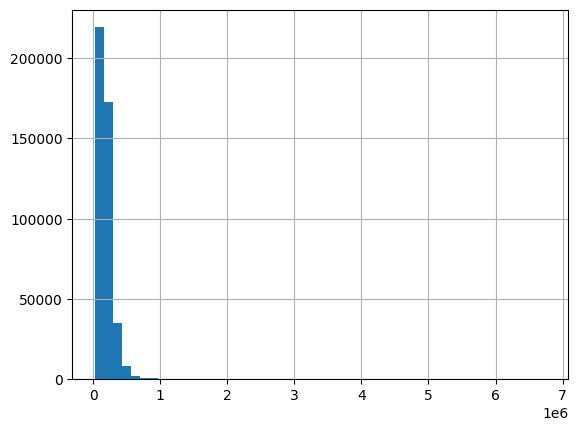

In [ ]:
#it will show the histogram distribution of income
application_data['AMT_INCOME_TOTAL'].hist(bins=50)

In [ ]:
#compressing the income values with log function
application_data['LOG_INCOME'] = np.log1p(application_data['AMT_INCOME_TOTAL'])

<Axes: >

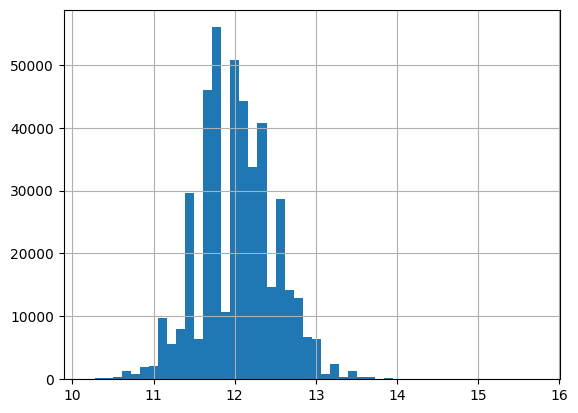

In [ ]:
#it will show the histogram distribution of log income
application_data['LOG_INCOME'].hist(bins=50)

<b>Discussion of Result?</b><br>
From the above distribution, we can see that the distribution is normal and we can't see any left skewed or right skewed in it means the log compressed the values. Because of this, the influence of outliers also reduced.

In [ ]:
#we are grouping to check the mean of target approved based on gender
gender_rates = application_data.groupby('CODE_GENDER')['TARGET_APPROVED'].mean()
gender_rates

,TARGET_APPROVED
CODE_GENDER,
F,0.082971
M,0.083453


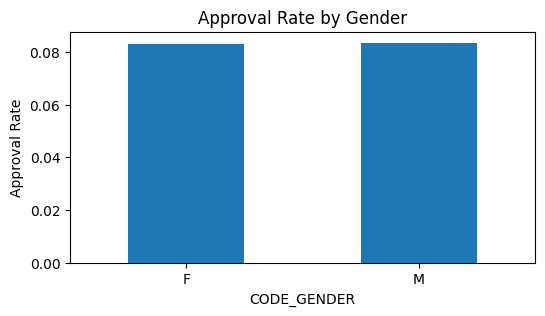

In [ ]:
#it will show a bar plot of approval rate by gender
plt.figure(figsize=(6,3))
gender_rates.plot(kind='bar')
plt.title('Approval Rate by Gender')
plt.ylabel('Approval Rate')
plt.xticks(rotation=0)
plt.show()

<b>Discussion of result?</b><br>
From the above bar plot, we can see that the both gender applicants have very slight difference in approval rate. Male applicants rate is ~0.0829 and Female applicants rate is ~0.0834.

In [ ]:
#we are grouping to check the mean of target approved based on own car flag
car_rates = application_data.groupby('FLAG_OWN_CAR')['TARGET_APPROVED'].mean()
car_rates

,TARGET_APPROVED
FLAG_OWN_CAR,
N,0.082096
Y,0.084875


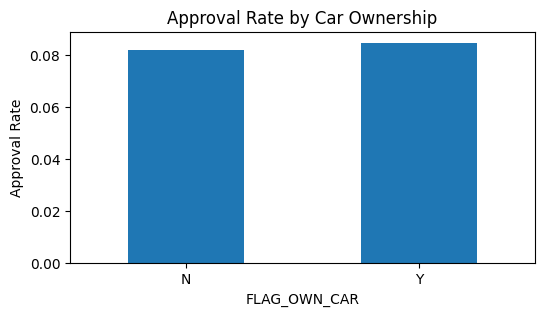

In [ ]:
#it will show a bar plot of approval rate by car ownership
plt.figure(figsize=(6,3))
car_rates.plot(kind='bar')
plt.title('Approval Rate by Car Ownership')
plt.ylabel('Approval Rate')
plt.xticks(rotation=0)
plt.show()

<b>Discussion of result?</b><br>
From the above bar plot, we can see that the applicants who has car and the applicants who don't have car have very slight difference in approval rate. The applicants who has car, approval rate is ~0.0849 and the applicants who don't have car, approval rate is ~0.0821.

In [ ]:
#we are grouping to check the mean of target approved based on income type
inc_rates = application_data.groupby('NAME_INCOME_TYPE')['TARGET_APPROVED'].mean().sort_values()
inc_rates

,TARGET_APPROVED
NAME_INCOME_TYPE,
Pensioner,0.081491
State servant,0.082490
Working,0.083232
Commercial associate,0.084262
Student,0.647059


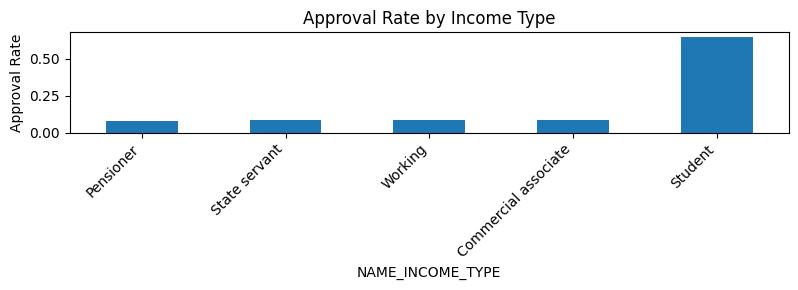

In [ ]:
#it will show a bar plot of approval rate by income type
plt.figure(figsize=(8,3))
inc_rates.plot(kind='bar')
plt.title('Approval Rate by Income Type')
plt.ylabel('Approval Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<b>Discussion of result?</b><br>
From the above bar plot, we can see that students credit card approval rate is higher than any other which is around ~0.65. Pensioners approval rate is ~0.085, State servants approval rate is around ~0.082, Working applicants approval rate is ~0.083, and Commercial associate approval rate is ~0.084.

In [ ]:
#we are grouping to check the mean of target approved based on education type
edu_rates = application_data.groupby('NAME_EDUCATION_TYPE')['TARGET_APPROVED'].mean().sort_values()
edu_rates

,TARGET_APPROVED
NAME_EDUCATION_TYPE,
Secondary / secondary special,0.082092
Higher education,0.083933
Lower secondary,0.092323
Incomplete higher,0.094943
Academic degree,0.102564


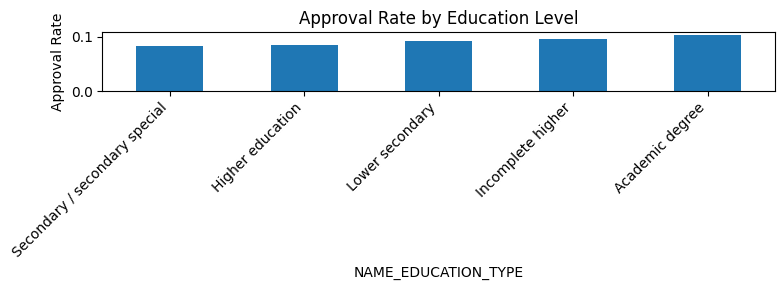

In [ ]:
#it will show a bar plot of approval rate by education level
plt.figure(figsize=(8,3))
edu_rates.plot(kind='bar')
plt.title('Approval Rate by Education Level')
plt.ylabel('Approval Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<b>Discussion of result?</b><br>
From the above bar plot, we can see that almost all the education levels are equal with very slight differences, if we compare the difference academic degree has high approval rate which is ~0.1026. Secondary education level applicants rate is ~0.0821, Higher education rate is ~0.0839, Lower secondary rate is ~0.0923, and Incomplete higher rate is ~0.0949.

In [ ]:
#we are grouping to check the mean of target approved based on marital status
fam_rates = application_data.groupby('NAME_FAMILY_STATUS')['TARGET_APPROVED'].mean().sort_values()
fam_rates

,TARGET_APPROVED
NAME_FAMILY_STATUS,
Separated,0.077171
Widow,0.077865
Civil marriage,0.080614
Married,0.083541
Single / not married,0.087370


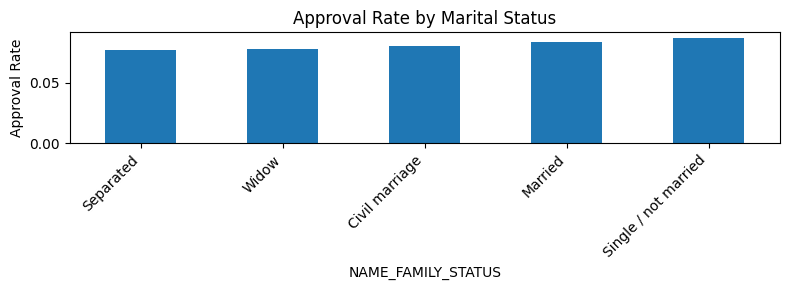

In [ ]:
#it will show a bar plot of approval rate by marital status
plt.figure(figsize=(8,3))
fam_rates.plot(kind='bar')
plt.title('Approval Rate by Marital Status')
plt.ylabel('Approval Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<b>Discussion of result?</b><br>
From the above bar plot, we can see that single/not married applicants have higher approval rate which is around ~0.0873 with slight difference with others. Separated applicants approval rate is ~0.077, Widow applicants approval rate is ~0.078, Civil marriage applicants approval rate is ~0.081, and Married applicants approval rate is ~0.084.

In [ ]:
#we are grouping to check the mean of target approved based on housing type
house_rates = application_data.groupby('NAME_HOUSING_TYPE')['TARGET_APPROVED'].mean().sort_values()
house_rates

,TARGET_APPROVED
NAME_HOUSING_TYPE,
Office apartment,0.066803
Municipal apartment,0.079358
House / apartment,0.082645
With parents,0.093096
Rented apartment,0.096250
Co-op apartment,0.109162


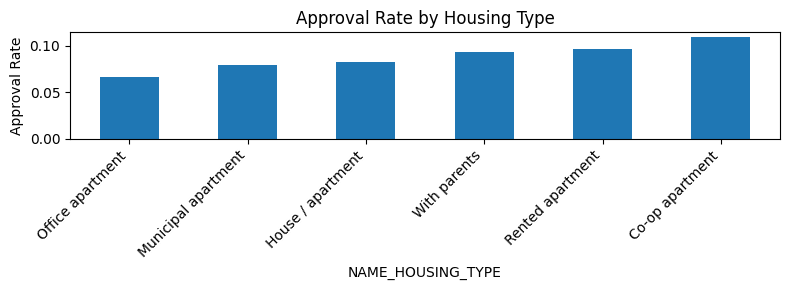

In [ ]:
#it will show a bar plot of approval rate by housing type
plt.figure(figsize=(8,3))
house_rates.plot(kind='bar')
plt.title('Approval Rate by Housing Type')
plt.ylabel('Approval Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<b>Discussion of result?</b><br>
From the above bar plot, we can see that Co-op apartment applicants have the highest approval rate, which is around ~0.110, with slight difference from the others. Office apartment approval rate is ~0.067, Municipal apartment approval rate is ~0.080, House / apartment approval rate is ~0.083, With parents approval rate is ~0.093, and Rented apartment approval rate is ~0.098.

In [ ]:
#checking the correlation between numeric columns
num_cols = ['AGE_YEARS','EMPLOY_YEARS','LOG_INCOME','CNT_CHILDREN','CNT_FAM_MEMBERS']
corr = application_data[num_cols + ['TARGET_APPROVED']].corr()
corr

,AGE_YEARS,EMPLOY_YEARS,LOG_INCOME,CNT_CHILDREN,CNT_FAM_MEMBERS,TARGET_APPROVED
AGE_YEARS,1.000000,0.348314,-0.091982,-0.349093,-0.306182,-0.001633
EMPLOY_YEARS,0.348314,1.000000,0.023377,-0.070132,-0.043864,0.002803
LOG_INCOME,-0.091982,0.023377,1.000000,0.023716,0.009306,-0.003365
CNT_CHILDREN,-0.349093,-0.070132,0.023716,1.000000,0.884781,0.001215
CNT_FAM_MEMBERS,-0.306182,-0.043864,0.009306,0.884781,1.000000,0.001338
TARGET_APPROVED,-0.001633,0.002803,-0.003365,0.001215,0.001338,1.000000


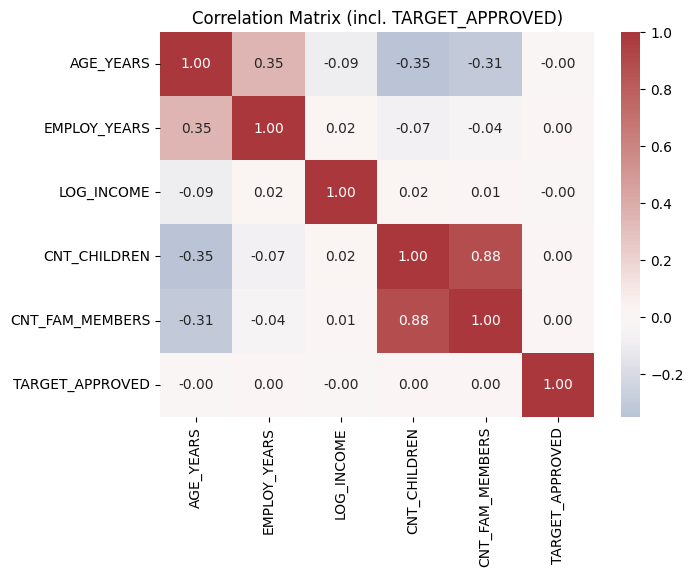

In [ ]:
#it will show a heat map of correlation matrix of numeric columns
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation Matrix (incl. TARGET_APPROVED)")
plt.show()

<b>Discussion of result?</b><br>
From the above correlation matrix, we can see that:

AGE_YEARS & EMPLOY_YEARS correlate at ~0.35, meaning older applicants generally have longer time on the job.
AGE_YEARS vs CNT_CHILDREN is ~–0.35, and vs CNT_FAM_MEMBERS is ~–0.31—older applicants tend to have fewer dependents living with them.
CNT_CHILDREN & CNT_FAM_MEMBERS are extremely collinear at ~0.88, so keeping both likely adds redundant information.
LOG_INCOME has only a tiny correlation (±0.02) with the other numerics, indicating income is fairly independent of age or family size on the log scale.
Crucially, all five numeric features have correlations with TARGET_APPROVED of essentially 0.00, which tells us there is no strong linear signal from these raw continuous variables alone—so we’ll need non-linear models or engineered interactions to capture their predictive power.

In [ ]:
#it will show a pairplot of numerics colored by approval
plt.figure(figsize=(12,8))
sns.pairplot(
    application_data[num_cols + ['TARGET_APPROVED']],
    hue='TARGET_APPROVED',
    vars=num_cols,
    plot_kws={'alpha':0.3, 's':20},
    diag_kind='hist'
)
plt.suptitle("Pairplot of Numerics Colored by Approval", y=1.02)
plt.show()

<b>Discussion of result?</b><br>
From the above pairplot of your five numeric features colored by approval, a few things stand out:

Heavy overlap between approved (orange) and rejected (blue) cases across every 2-D projection—there’s no clean “cluster” that separates approvals from rejections on these raw numerics alone.
In the AGE_YEARS vs EMPLOY_YEARS panels, points lie almost perfectly along the diagonal (older applicants have longer employment), but approved cases are sprinkled evenly along that line.
Looking at LOG_INCOME vs AGE_YEARS and LOG_INCOME vs EMPLOY_YEARS, there’s a very slight uptick in approved points at the upper-right (higher incomes and mid-career ages), but it’s far from a dominant effect.
For CNT_CHILDREN and CNT_FAM_MEMBERS, the counts form distinct “strata” (0, 1, 2, …), and again approvals appear in each layer—no one family size leaps out as a silver bullet.
Overall, this confirms our correlation findings: no single pair of numeric features gives a strong linear or two-feature separation.

In [ ]:
#pivot table to calculate the average approval rate for each combination of income type and education level
pivot = (application_data.pivot_table(index='NAME_INCOME_TYPE',columns='NAME_EDUCATION_TYPE',values='TARGET_APPROVED',aggfunc='mean'))

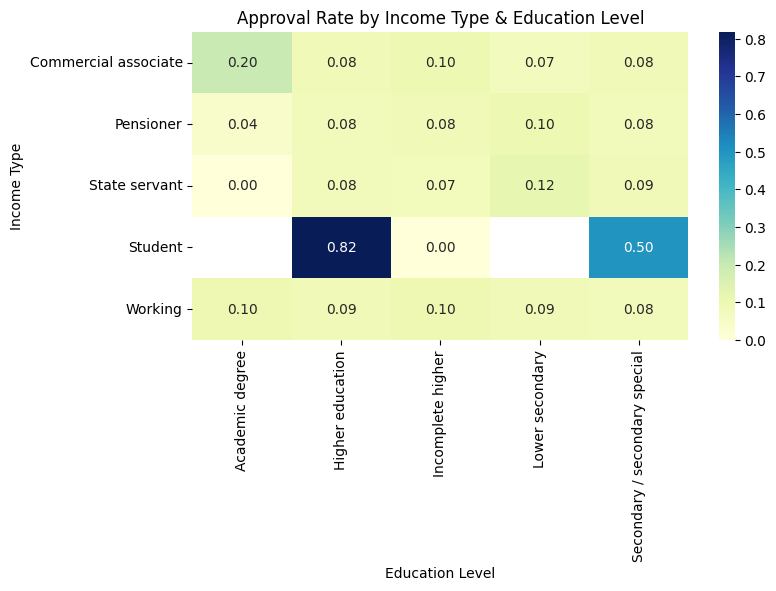

In [ ]:
#it will show us a approval rate by income type and education level
plt.figure(figsize=(8,4))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Approval Rate by Income Type & Education Level")
plt.ylabel("Income Type")
plt.xlabel("Education Level")
plt.show()

<b>Discussion of result?</b><br>
From the above heatmap, we can see that Student applicants with Higher education have the highest approval rate, which is around ~0.82, followed by Student with Secondary / secondary special at ~0.50. Among non-students, Commercial associate with Academic degree come next at ~0.20, and State servant with Lower secondary at ~0.12. Pensioner and Working applicants cluster around ~0.08–0.10 approval across most education levels. Notably, State servant with Academic degree show effectively ~0.00 approval.

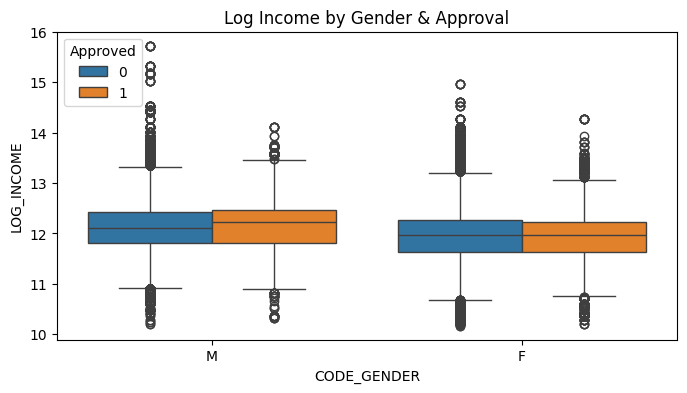

In [ ]:
#it will show a box plot of log income by gender and approval
plt.figure(figsize=(8,4))
sns.boxplot(
    data=application_data,
    x='CODE_GENDER',
    y='LOG_INCOME',
    hue='TARGET_APPROVED'
)
plt.title("Log Income by Gender & Approval")
plt.ylabel("LOG_INCOME")
plt.legend(title="Approved", loc='upper left')
plt.show()

<b>Discussion of result?</b><br>
From the above boxplot, we can see that approved applicants tend to have slightly higher incomes than rejected, for both genders. For male applicants, the median LOG_INCOME is about 12.3 for approved vs 12.1 for rejected. For female applicants, approved medians sit around 12.0 compared to 11.9 for rejected. Male incomes also show a wider spread and more extreme high-end outliers. Overall, higher income is modestly associated with approval across both genders.

<h2>MODEL BUILDING</h2>

- **Feature Selection:**  
  - **Numerical:** Age (`AGE_YEARS`), Employment duration (`EMPLOY_YEARS`), Log-transformed income (`LOG_INCOME`), Number of children, Family size.  
  - **Categorical:** Gender, Car/realty ownership, Income type, Education level, Family status, Housing type, Occupation.

- **Data Split:**  
  - 80% training, 20% test, stratified on the approval label to preserve class balance.

- **Preprocessing Pipeline:**  
  - Standard scaling for numeric features.  
  - One-hot encoding for categorical features.

- **Model:**  
  - LightGBM classifier with 500 trees and balanced class weights to handle the 8% approval rate.

- **Training & Evaluation:**  
  - Trained the full pipeline on the training set.  
  - Evaluated using ROC-AUC, accuracy, precision, recall, F1-score, and confusion matrices on both train and test.

- **Performance:**  
  - **Train ROC-AUC:** ~ 0.90  
  - **Test ROC-AUC:** ~ 0.85  
  - Balanced recall on rejections (~ 80%) and approvals (~ 74%) at the default threshold.

In [ ]:
#specifying lists of continuous and categorical features to include in the model
NUM_FEATS = ['AGE_YEARS','EMPLOY_YEARS','LOG_INCOME','CNT_CHILDREN','CNT_FAM_MEMBERS']
CAT_FEATS = ['CODE_GENDER','FLAG_OWN_CAR','FLAG_OWN_REALTY',
             'NAME_INCOME_TYPE','NAME_EDUCATION_TYPE',
             'NAME_FAMILY_STATUS','NAME_HOUSING_TYPE','OCCUPATION_TYPE']

In [ ]:
#created the feature matrix X and target vector y
X = application_data[NUM_FEATS + CAT_FEATS]
y = application_data['TARGET_APPROVED']

In [ ]:
#split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [ ]:
#it will standardize numeric features and one-hot encode categorical features
preproc = ColumnTransformer([
    ('num', StandardScaler(), NUM_FEATS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEATS)
])

In [ ]:
#it will apply preprocessing then train a LightGBM classifier
pipe = Pipeline([
    ('preproc', preproc),
    ('clf', LGBMClassifier(n_estimators=500,
                           class_weight='balanced',
                           random_state=42))
])

In [ ]:
#trained the full pipeline
pipe.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 29166, number of negative: 321679
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031449 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 835
[LightGBM] [Info] Number of data points in the train set: 350845, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['AGE_YEARS', 'EMPLOY_YEARS',
                                                   'LOG_INCOME', 'CNT_CHILDREN',
                                                   'CNT_FAM_MEMBERS']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['CODE_GENDER',
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'OCCUPATION_TYPE'])])),
                ('clf',
                 LGBMClassifier(class_weight='balanced', n_estimators=500,
                                random_state=42))])

In [ ]:
#it will generate predicted probabilities and class labels
y_train_pred_proba = pipe.predict_proba(X_train)[:, 1]
y_train_pred       = pipe.predict(X_train)

In [ ]:
print(f"ROC-AUC : {roc_auc_score(y_train, y_train_pred_proba):.4f}")

ROC-AUC : 0.9013


In [ ]:
print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")

Accuracy: 0.8124


In [ ]:
print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       0.98      0.81      0.89    321679
           1       0.28      0.81      0.42     29166

    accuracy                           0.81    350845
   macro avg       0.63      0.81      0.65    350845
weighted avg       0.92      0.81      0.85    350845



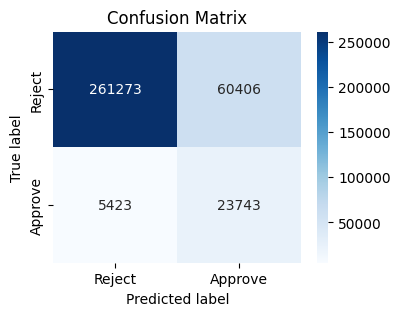

In [ ]:
#it will show confusion matrix for train predictions vs actual
cm = confusion_matrix(y_train, y_train_pred)
labels = ['Reject','Approve']

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

<b>Discussion of result?</b><br>
From the above confusion matrix, we can see that:<br>
Rejections (top row)<br>
Out of about 322 k people who actually should have been rejected, the model correctly rejects 261 k (~ 81%) but mistakenly approves 60 k (~ 19%).<br>
Approvals (bottom row)<br>
Of the roughly 29 k people who really were approved, it catches 24 k (~ 81%) but wrongly rejects 5.4 k (~ 19%).

In [ ]:
#it will generate predicted probabilities and class labels
y_test_pred_proba = pipe.predict_proba(X_test)[:, 1]
y_test_pred       = pipe.predict(X_test)

In [ ]:
print(f"ROC-AUC : {roc_auc_score(y_test, y_test_pred_proba):.4f}")

ROC-AUC : 0.8508


In [ ]:
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")

Accuracy: 0.7982


In [ ]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.97      0.80      0.88     80421
           1       0.25      0.74      0.38      7291

    accuracy                           0.80     87712
   macro avg       0.61      0.77      0.63     87712
weighted avg       0.91      0.80      0.84     87712



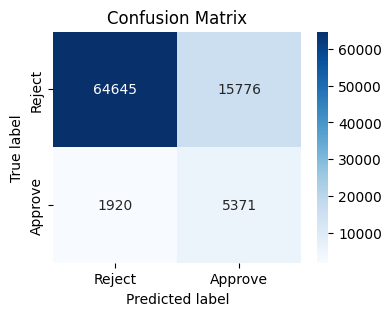

In [ ]:
#it will show confusion matrix for test predictions vs actual
cm = confusion_matrix(y_test, y_test_pred)
labels = ['Reject','Approve']

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

<b>Discussion of result?</b><br>
From the above confusion matrix, we can see that:<br>
Rejections (top row)<br>
Out of 80421 applicants who truly should have been rejected, the model correctly rejects 64645 (~ 80 %) but mistakenly approves 15776 (~ 20 %).<br>
Approvals (bottom row)<br>
Of the 7291 applicants who were actually approved, it correctly approves 5371 (~ 74 %) but wrongly rejects 1920 (~ 26 %).

## Handling Class Imbalance with SMOTE

- **Why SMOTE?**  
  Our approval rate is only ~8%, so the model sees far fewer “approved” examples. SMOTE (Synthetic Minority Oversampling TEchnique) creates new, synthetic approved samples by interpolating between existing ones, giving the classifier more varied positive examples to learn from.

- **How it’s used**  
  We insert SMOTE into our imblearn pipeline **after** preprocessing and **before** fitting LightGBM.

In [ ]:
#it will median-impute missing numeric values and then standardize them
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

In [ ]:
#it will apply the numeric pipeline to NUM_FEATS and one-hot encode the CAT_FEATS
preproc = ColumnTransformer([
    ('num', num_pipeline, NUM_FEATS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEATS)
])

In [ ]:
#it will apply preprocessing then SMOTE then train a LightGBM classifier
imb_pipe = imbpipeline([
    ('preproc', preproc),
    ('smote',   SMOTE(random_state=42)),
    ('clf',     LGBMClassifier(
                    n_estimators=500,
                    class_weight='balanced',
                    random_state=42))
])

In [ ]:
#trained the full pipeline
imb_pipe.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 321679, number of negative: 321679
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.279550 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9987
[LightGBM] [Info] Number of data points in the train set: 643358, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['AGE_YEARS', 'EMPLOY_YEARS',
                                                   'LOG_INCOME', 'CNT_CHILDREN',
                                                   'CNT_FAM_MEMBERS']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['CODE_GENDER',
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'OCCUPATION_TYPE'])])),
                ('smote', SMOTE(random_state=42)),
                ('clf',
                 LGBMClassifier(class_weight='balanced', n_estimators=500,
                                random_state=42))])

In [ ]:
#it will generate predicted probabilities and class labels
y_test_pr = imb_pipe.predict_proba(X_test)[:,1]
y_test_p  = imb_pipe.predict(X_test)

In [ ]:
print(f"Accuracy: {accuracy_score(y_test, y_test_p):.4f}")

Accuracy: 0.8801


In [ ]:
print(classification_report(y_test, y_test_p))

              precision    recall  f1-score   support

           0       0.95      0.91      0.93     80421
           1       0.35      0.52      0.42      7291

    accuracy                           0.88     87712
   macro avg       0.65      0.72      0.68     87712
weighted avg       0.90      0.88      0.89     87712



In [ ]:
print(confusion_matrix(y_test, y_test_p))

[[73388  7033]
 [ 3485  3806]]


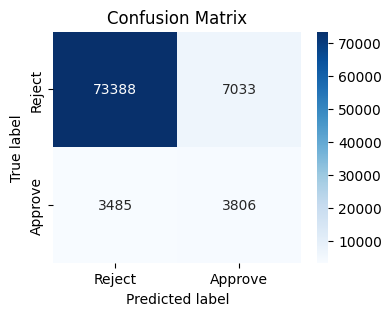

In [ ]:
#it will show confusion matrix for test predictions vs actual
cm = confusion_matrix(y_test, y_test_p)
labels = ['Reject','Approve']

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

<b>Discussion of Result?</b><br>
From the above confusion matrix, we can see that:<br>
Rejections (top row)<br>
Out of 80421 applicants who truly should have been rejected, the model correctly rejects 73388 (~ 0.91) but mistakenly approves 7 033 (~ 0.09).<br>
Approvals (bottom row)<br>
Of the 7291 applicants who truly were approved, it correctly approves 3806 (~ 0.52) but wrongly rejects 3485 (~ 0.48).

So after SMOTE, we have boosted precision on “Approve” (fewer bad approvals), but recall on approvals drops to about 52%—we now miss almost half of the real positives.